In [1]:
# ============================================================================
# TASK 2.6 ANALYSIS - OPTIMIZED VERSION
# ============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import Dict, List, Tuple, Optional, Union
import warnings
from scipy.stats import entropy
import logging

# Configure logging for better debugging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)

# Set style for consistent plotting
plt.style.use('default')
sns.set_palette("husl")

In [2]:
# ============================================================================
# TASK 2.6 DATA PROCESSOR CLASS - CENTRALIZED LOGIC
# ============================================================================

class Task26DataProcessor:
    """
    Centralized class for processing Task 2.6 data with all mapping dictionaries 
    and utility functions to eliminate code redundancy.
    """
    
    # CONSOLIDATED MAPPING DICTIONARIES
    ANSWER_CODES = {
        "simpleAssociableChoice_1373281683439": "Forsterker",
        "simpleAssociableChoice_1373281683440": "Minne", 
        "simpleAssociableChoice_IA1733059374798088f79fc-c80c-418d-bf6c-83b7028c355d": "NAND",
        "simpleAssociableChoice_IA17330593760746b76266e-e419-4737-9004-52278caeda7d": "Inverter",
    }

    POSITION_CODES = {
        "simpleAssociableChoice_1373281683441": {"name": "0%", "percentage": 0, "order": 1, "display": "0%"},
        "simpleAssociableChoice_1373281683442": {"name": "25%", "percentage": 25, "order": 2, "display": "25%"}, 
        "simpleAssociableChoice_IA1733059325124ad7c9083-b503-4bd5-9ae3-f6e34e0be86f": {"name": "50%", "percentage": 50, "order": 3, "display": "50%"},
        "simpleAssociableChoice_IA173305932680487bc7540-f571-4dc4-8526-94b1a55b9bd7": {"name": "75%", "percentage": 75, "order": 4, "display": "75%"},
        "simpleAssociableChoice_IA173305934600265968bd2-21e4-4825-87ea-3bc1591eb528": {"name": "100%", "percentage": 100, "order": 5, "display": "100%"}
    }
    
    def __init__(self):
        self.complete_mapping = {**self.ANSWER_CODES, **{k: v["display"] for k, v in self.POSITION_CODES.items()}}
        self.position_0_percent = self._get_position_code_by_percentage(0)
        
    def _get_position_code_by_percentage(self, percentage: int) -> Optional[str]: #Optional will either return a string (the code) or None if not found
        """Get position code for a specific percentage value."""
        for code, info in self.POSITION_CODES.items():
            if info['percentage'] == percentage:
                return code
        return None

    def parse_response_code(self, code: Union[str, float, None]) -> Optional[Tuple[str, str]]:
        """Parse a Task 2.6 response code into (chosen_answer, position)."""
        # handle missing or invalid responses
        if pd.isna(code) or str(code).strip() in {'No Response', 'nan', 'None'}:
            return None
        
        parts = str(code).split(' ')
        return (parts[0], parts[1]) if len(parts) == 2 else None

    def get_answer_name(self, answer_code: str) -> str:
        """Map answer codes to descriptive text."""
        return self.ANSWER_CODES.get(answer_code, answer_code.split('_')[-1][:15])

    def get_position_info(self, position_code: str) -> Dict[str, Union[str, int]]:
        """Get detailed position information."""
        return self.POSITION_CODES.get(position_code, 
            {"name": "Unknown Position", "percentage": -1, "order": 999, "display": "Unknown Position"})

    def load_and_validate_data(self, file_path: str = "../data/cleaned_data/IN1020_2024_cleaned_data.csv") -> pd.DataFrame:
        """Load and validate exam data with enhanced error handling."""
        try:
            df = pd.read_csv(file_path)
            logger.info(f"Loaded data: {len(df)} rows, {len(df.columns)} columns")
            
            # Check unique question numbers for debugging
            unique_questions = sorted(df['question_number'].unique())
            logger.info(f"Unique question numbers: {unique_questions}")
            
            # Validate required columns
            required_columns = ['student_id', 'question_number', 'candidate_response_text', 'candidate_response_code']
            missing_cols = [col for col in required_columns if col not in df.columns]
            if missing_cols:
                logger.warning(f"Missing columns: {missing_cols}")
            
            return df
        except Exception as e:
            logger.error(f"Error loading data: {e}")
            raise

    def get_task_data(self, df: pd.DataFrame, question_number: Union[str, float] = 2.6) -> pd.DataFrame:
        """Get task-specific data with validation."""
        task_data = df[df['question_number'] == question_number].copy()
        logger.info(f"Retrieved {len(task_data)} responses for Task {question_number}")
        return task_data

    def calculate_grade_thresholds(self, max_score: float) -> Dict[str, float]:
        """Calculate adjusted grade thresholds based on max score."""
        original_thresholds = {'A': 92, 'B': 77, 'C': 58, 'D': 46, 'E': 40, 'F': 0}
        return {grade: round((original / 100) * max_score, 2) 
                for grade, original in original_thresholds.items()}

    def assign_grade(self, score: float, thresholds: Dict[str, float]) -> str:
        """Assign grade based on score and thresholds."""
        if pd.isna(score):
            return 'F'
        for grade in ['A', 'B', 'C', 'D', 'E']:
            if score >= thresholds[grade]:
                return grade
        return 'F'

    def assign_quartile(self, score: float, q1: float, q2: float, q3: float) -> str:
        """Assign quartile based on score."""
        if pd.isna(score):
            return 'Q1'
        if score >= q3:
            return 'Q4'
        elif score >= q2:
            return 'Q3'
        elif score >= q1:
            return 'Q2'
        return 'Q1'

# Initialize the processor (create/initialize the class instance (object from the class))
processor = Task26DataProcessor()

# Load and validate data
df = processor.load_and_validate_data()

# Calculate max score and grade thresholds
max_score = df['auto_total_score'].max()
grade_thresholds = processor.calculate_grade_thresholds(max_score)

logger.info(f"Max score: {max_score}")
logger.info(f"Grade thresholds: {grade_thresholds}")

2025-10-30 15:16:59,963 - INFO - Loaded data: 65880 rows, 14 columns
2025-10-30 15:16:59,967 - INFO - Unique question numbers: [np.float64(1.1), np.float64(1.2), np.float64(1.3), np.float64(1.4), np.float64(1.5), np.float64(1.6), np.float64(1.7), np.float64(1.8), np.float64(2.1), np.float64(2.2), np.float64(2.3), np.float64(2.4), np.float64(2.5), np.float64(2.6), np.float64(3.1), np.float64(3.2), np.float64(3.3), np.float64(3.4), np.float64(3.5), np.float64(3.6), np.float64(3.7), np.float64(3.8), np.float64(4.1), np.float64(4.2), np.float64(4.3), np.float64(4.4), np.float64(4.5), np.float64(4.6), np.float64(4.7), np.float64(4.8)]
2025-10-30 15:16:59,969 - INFO - Max score: 91.85
2025-10-30 15:16:59,970 - INFO - Grade thresholds: {'A': 84.5, 'B': 70.72, 'C': 53.27, 'D': 42.25, 'E': 36.74, 'F': 0.0}
2025-10-30 15:16:59,967 - INFO - Unique question numbers: [np.float64(1.1), np.float64(1.2), np.float64(1.3), np.float64(1.4), np.float64(1.5), np.float64(1.6), np.float64(1.7), np.float64(1.

In [3]:
# ============================================================================
# TASK 2.6 DATA ANALYZER CLASS - CONSOLIDATED ANALYSIS LOGIC
# ============================================================================

class Task26DataAnalyzer:
    """
    Centralized class for analyzing Task 2.6 data with all analysis functions
    to eliminate code redundancy and improve efficiency.
    """
    
    def __init__(self, processor: Task26DataProcessor):
        self.processor = processor
        self.task_data = None
        self.pivot_data = None
        self.student_combinations = None
        
    def prepare_data(self, df: pd.DataFrame) -> pd.DataFrame:
        """Prepare and clean Task 2.6 data for analysis."""
        logger.info("Preparing Task 2.6 data...")
        
        # Get task data (using float 2.6 instead of string '2.6')
        self.task_data = self.processor.get_task_data(df, 2.6)
        
        # Parse responses and create working dataset
        parsed_responses = []
        for _, row in self.task_data.iterrows():
            parsed = self.processor.parse_response_code(row['candidate_response_code'])
            if parsed:
                answer_code, position_code = parsed
                answer_name = self.processor.get_answer_name(answer_code)
                position_info = self.processor.get_position_info(position_code)
                
                parsed_responses.append({
                    'student_id': row['student_id'],
                    'answer_name': answer_name,
                    'percentage': position_info['percentage'],
                    'duration_minutes': row.get('question_duration_sec', 0) / 60.0
                })
        
        # Convert to DataFrame
        working_data = pd.DataFrame(parsed_responses)
        
        # Create pivot table for combinations
        if not working_data.empty:
            self.pivot_data = working_data.pivot_table(
                index='student_id',
                columns='answer_name',
                values='percentage',
                fill_value=0
            )
            
            # Ensure all columns exist
            expected_columns = ["Minne", "Forsterker", "NAND", "Inverter"]
            for col in expected_columns:
                if col not in self.pivot_data.columns:
                    self.pivot_data[col] = 0
            
            self.pivot_data = self.pivot_data[expected_columns]
            
            # Create combination strings
            self.pivot_data['combination'] = self.pivot_data.apply(self._create_combination_string, axis=1)
            
        logger.info(f"Prepared data for {len(self.pivot_data) if self.pivot_data is not None else 0} students")
        return working_data
    
    def _create_combination_string(self, row) -> str:
        """Create readable combination string."""
        parts = []
        mapping = {"Minne": "M", "Forsterker": "F", "NAND": "N", "Inverter": "I"}
        for col in ["Minne", "Forsterker", "NAND", "Inverter"]:
            percentage = row[col]
            if percentage > 0:
                parts.append(f"{mapping[col]}{int(percentage)}")
        return "-".join(parts) if parts else "None"
    
    def analyze_percentage_sums(self) -> Dict:
        """Analyze percentage sums for students."""
        logger.info("Analyzing percentage sums...")
        
        if self.pivot_data is None or len(self.pivot_data) == 0:
            logger.warning("No pivot data available - creating empty analysis")
            return {
                'sums_distribution': pd.Series(dtype=int),
                'students_with_100': 0,
                'total_students': 0
            }
        
        # Calculate sums
        sums = self.pivot_data[["Minne", "Forsterker", "NAND", "Inverter"]].sum(axis=1)
        
        # Create distribution
        sums_distribution = sums.value_counts().sort_index()
        
        return {
            'sums_distribution': sums_distribution,
            'students_with_100': len(sums[sums == 100]),
            'total_students': len(sums)
        }
    
    def filter_by_sum(self, target_sum: int = 100) -> pd.DataFrame:
        """Filter students by percentage sum."""
        logger.info(f"Filtering students with sum = {target_sum}%...")
        
        if self.pivot_data is None or len(self.pivot_data) == 0:
            logger.warning("No pivot data available for filtering")
            return pd.DataFrame()
        
        # Calculate sums and filter
        sums = self.pivot_data[["Minne", "Forsterker", "NAND", "Inverter"]].sum(axis=1)
        valid_students = sums[sums == target_sum].index
        
        # Filter original task data
        filtered_data = self.task_data[self.task_data['student_id'].isin(valid_students)].copy()
        
        logger.info(f"Filtered to {len(valid_students)} students with sum = {target_sum}%")
        return filtered_data
    
    def complete_missing_responses(self, filtered_data: pd.DataFrame) -> pd.DataFrame:
        """Add missing options with 0% for incomplete students."""
        logger.info("Completing missing responses...")
        
        if len(filtered_data) == 0:
            logger.warning("No filtered data to complete")
            return filtered_data
        
        # Analyze completeness
        student_responses = {}
        for _, row in filtered_data.iterrows():
            student_id = row['student_id']
            parsed = self.processor.parse_response_code(row['candidate_response_code'])
            if parsed:
                answer_code, position_code = parsed
                if student_id not in student_responses:
                    student_responses[student_id] = set()
                student_responses[student_id].add(answer_code)
        
        # Find incomplete students
        all_answer_codes = set(self.processor.ANSWER_CODES.keys())
        incomplete_students = []
        
        for student_id, chosen_codes in student_responses.items():
            missing_codes = all_answer_codes - chosen_codes
            if missing_codes:
                incomplete_students.append({
                    'student_id': student_id,
                    'missing_codes': missing_codes
                })
        
        # Add missing responses
        if incomplete_students:
            sample_row = filtered_data.iloc[0].copy()
            new_rows = []
            
            for student_info in incomplete_students:
                for missing_code in student_info['missing_codes']:
                    new_row = sample_row.copy()
                    new_row['student_id'] = student_info['student_id']
                    new_row['candidate_response_code'] = f"{missing_code} {self.processor.position_0_percent}"
                    new_row['candidate_response_text'] = self.processor.get_answer_name(missing_code)
                    new_rows.append(new_row)
            
            if new_rows:
                new_rows_df = pd.DataFrame(new_rows)
                filtered_data = pd.concat([filtered_data, new_rows_df], ignore_index=True)
                logger.info(f"Added {len(new_rows)} missing responses")
        
        return filtered_data

# Initialize analyzer
analyzer = Task26DataAnalyzer(processor)

# Prepare data
working_data = analyzer.prepare_data(df)

# Analyze percentage sums
sums_analysis = analyzer.analyze_percentage_sums()
logger.info(f"Students with 100% sum: {sums_analysis['students_with_100']}/{sums_analysis['total_students']}")

# Filter and complete data
filtered_data = analyzer.filter_by_sum(100)
complete_data = analyzer.complete_missing_responses(filtered_data)

2025-10-30 15:16:59,993 - INFO - Preparing Task 2.6 data...
2025-10-30 15:16:59,999 - INFO - Retrieved 1976 responses for Task 2.6
2025-10-30 15:16:59,999 - INFO - Retrieved 1976 responses for Task 2.6
2025-10-30 15:17:00,143 - INFO - Prepared data for 561 students
2025-10-30 15:17:00,144 - INFO - Analyzing percentage sums...
2025-10-30 15:17:00,147 - INFO - Students with 100% sum: 543/561
2025-10-30 15:17:00,148 - INFO - Filtering students with sum = 100%...
2025-10-30 15:17:00,152 - INFO - Filtered to 543 students with sum = 100%
2025-10-30 15:17:00,152 - INFO - Completing missing responses...
2025-10-30 15:17:00,143 - INFO - Prepared data for 561 students
2025-10-30 15:17:00,144 - INFO - Analyzing percentage sums...
2025-10-30 15:17:00,147 - INFO - Students with 100% sum: 543/561
2025-10-30 15:17:00,148 - INFO - Filtering students with sum = 100%...
2025-10-30 15:17:00,152 - INFO - Filtered to 543 students with sum = 100%
2025-10-30 15:17:00,152 - INFO - Completing missing responses

In [ ]:
# ============================================================================
# TASK 2.6 VISUALIZATION CLASS - CONSOLIDATED PLOTTING FUNCTIONS
# ============================================================================

class Task26Visualizer:
    """
    Centralized class for creating all Task 2.6 visualizations
    to eliminate code redundancy and ensure consistent styling.
    """
    
    def __init__(self, processor: Task26DataProcessor, analyzer: Task26DataAnalyzer):
        self.processor = processor
        self.analyzer = analyzer
        self.colors = {
            'Minne': '#2E86AB',
            'Forsterker': '#A23B72', 
            'Inverter': '#F18F01',
            'NAND': '#C73E1D',
            'Other': '#808080'
        }
    
    def create_base_plot(self, figsize=(12, 8), title="", xlabel="", ylabel=""):
        """Create base plot with consistent styling."""
        fig, ax = plt.subplots(figsize=figsize)
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
        ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        return fig, ax
    
    def plot_percentage_distribution(self, sums_analysis: Dict, bins=None):
        """Create histogram of percentage sum distribution."""
        if bins is None:
            bins = [0, 25, 50, 75, 100, 125, 150, 200, 250]
        
        fig, ax = self.create_base_plot(
            figsize=(12, 8),
            title='Task 2.6: Distribution of Percentage Sum per Student',
            xlabel='Sum Bins (%)',
            ylabel='Number of Students'
        )
        
        distribution = sums_analysis['sums_distribution']
        total_students = sums_analysis['total_students']
        
        # Create bin counts
        bin_counts = [distribution.get(bin_val, 0) for bin_val in bins]
        colors = ['green' if bin_val == 100 else 'grey' for bin_val in bins]
        
        bars = ax.bar(range(len(bins)), bin_counts, color=colors, alpha=0.7, 
                      edgecolor='black', linewidth=1)
        
        # Add labels
        ax.set_xticks(range(len(bins)))
        ax.set_xticklabels([f'{bin_val}%' for bin_val in bins], rotation=45)
        
        # Add value labels
        for bar, count in zip(bars, bin_counts):
            if count > 0:
                height = bar.get_height()
                percentage = (count / total_students) * 100
                ax.annotate(f'{count}\n({percentage:.1f}%)',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 3), textcoords="offset points",
                           ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    
    def plot_combination_distribution(self, combination_data: pd.DataFrame, top_n=15):
        """Create bar chart of answer combination patterns."""
        combination_counts = combination_data['combination'].value_counts().head(top_n)
        total_students = len(combination_data)
        
        fig, ax = self.create_base_plot(
            figsize=(18, 10),
            title=f'Task 2.6: Top {top_n} Answer Combination Patterns',
            xlabel='Answer Combination Patterns\n(M=Minne, F=Forsterker, N=NAND, I=Inverter)',
            ylabel='Number of Students'
        )
        
        # Create gradient colors
        colors = plt.cm.viridis(np.linspace(0, 1, len(combination_counts)))
        
        bars = ax.bar(range(len(combination_counts)), combination_counts.values, 
                      color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Set labels
        ax.set_xticks(range(len(combination_counts)))
        ax.set_xticklabels(combination_counts.index, rotation=45, ha='right', fontsize=10)
        
        # Add value labels
        for bar, count in zip(bars, combination_counts.values):
            height = bar.get_height()
            percentage = (count / total_students) * 100
            ax.annotate(f'{count}\n({percentage:.1f}%)',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3), textcoords="offset points",
                       ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        return combination_counts
    
    def plot_grade_heatmap(self, df: pd.DataFrame, combination_data: pd.DataFrame, top_n=10):
        """Create heatmap showing grade-specific answer distributions."""
        # Get student grades
        student_scores = df[['student_id', 'auto_total_score']].drop_duplicates()
        grade_thresholds = self.processor.calculate_grade_thresholds(df['auto_total_score'].max())
        student_scores['grade'] = student_scores['auto_total_score'].apply(
            lambda x: self.processor.assign_grade(x, grade_thresholds)
        )
        
        # Get top combinations
        top_combinations = combination_data['combination'].value_counts().head(top_n).index.tolist()
        
        # Merge with grades
        combo_with_grades = combination_data.merge(student_scores[['student_id', 'grade']], on='student_id')
        
        # Create heatmap data
        grades = ['A', 'B', 'C', 'D', 'E', 'F']
        grade_totals = student_scores['grade'].value_counts()
        
        heatmap_data = []
        for combination in top_combinations:
            combo_data = combo_with_grades[combo_with_grades['combination'] == combination]
            grade_percentages = []
            
            for grade in grades:
                grade_total = grade_totals.get(grade, 0)
                combo_grade_count = len(combo_data[combo_data['grade'] == grade])
                percentage = (combo_grade_count / grade_total * 100) if grade_total > 0 else 0
                grade_percentages.append(percentage)
            
            heatmap_data.append(grade_percentages)
        
        # Create heatmap
        fig, ax = plt.subplots(figsize=(12, 14))
        heatmap_array = np.array(heatmap_data)
        
        sns.heatmap(heatmap_array, annot=True, fmt='.1f', cmap='Blues',
                    cbar_kws={'label': 'Percentage of Students Within Each Grade (%)'},
                    linewidths=0.5, linecolor='white', vmax=50, ax=ax)
        
        # Customize labels
        y_labels = [f"#{i+1}: {combo}" for i, combo in enumerate(top_combinations)]
        x_labels = [f"Grade {grade}\n({grade_totals.get(grade, 0)} students)" for grade in grades]
        
        ax.set_yticklabels(y_labels, rotation=0, fontsize=9)
        ax.set_xticklabels(x_labels, rotation=0, fontsize=10)
        
        plt.title('Task 2.6: Grade-Specific Answer Distribution Heatmap', 
                  fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()
    
    def plot_quartile_heatmap(self, df: pd.DataFrame, combination_data: pd.DataFrame):
        """Create heatmap showing quartile-specific answer distributions."""
        # Get student quartiles
        student_scores = df[['student_id', 'auto_total_score']].drop_duplicates()
        q1, q2, q3 = student_scores['auto_total_score'].quantile([0.25, 0.5, 0.75])
        student_scores['quartile'] = student_scores['auto_total_score'].apply(
            lambda x: self.processor.assign_quartile(x, q1, q2, q3)
        )
        
        # Categorize combinations
        def categorize_combination(combo):
            if 'M100' in combo: return 'M100'
            elif 'M75' in combo: return 'M75'
            elif 'M50' in combo: return 'M50'
            elif combo == 'F100': return 'F100'
            elif 'F75' in combo: return 'F75'
            elif 'F50' in combo: return 'F50'
            elif combo == 'I100': return 'I100'
            elif 'I75' in combo: return 'I75'
            elif 'I50' in combo: return 'I50'
            elif combo == 'N100': return 'N100'
            elif 'N75' in combo: return 'N75'
            elif 'N50' in combo: return 'N50'
            else: return 'Others'
        
        combination_data['category'] = combination_data['combination'].apply(categorize_combination)
        
        # Merge with quartiles
        combo_with_quartiles = combination_data.merge(student_scores[['student_id', 'quartile']], on='student_id')
        
        # Create heatmap data
        quartiles = ['Q4', 'Q3', 'Q2', 'Q1']
        quartile_totals = student_scores['quartile'].value_counts()
        categories = ['M100', 'M75', 'M50', 'F100', 'F75', 'F50', 'I100', 'I75', 'I50', 'N100', 'N75', 'N50', 'Others']
        
        # Filter available categories
        available_categories = [cat for cat in categories 
                               if len(combo_with_quartiles[combo_with_quartiles['category'] == cat]) > 0]
        
        heatmap_data = []
        for quartile in quartiles:
            quartile_percentages = []
            for category in available_categories:
                category_data = combo_with_quartiles[
                    (combo_with_quartiles['quartile'] == quartile) & 
                    (combo_with_quartiles['category'] == category)
                ]
                quartile_total = quartile_totals.get(quartile, 0)
                percentage = (len(category_data) / quartile_total * 100) if quartile_total > 0 else 0
                quartile_percentages.append(percentage)
            heatmap_data.append(quartile_percentages)
        
        # Create heatmap
        fig, ax = plt.subplots(figsize=(16, 10))
        heatmap_array = np.array(heatmap_data)
        
        sns.heatmap(heatmap_array, annot=True, fmt='.1f', cmap='Blues',
                    cbar_kws={'label': 'Percentage of Students Within Each Quartile (%)'},
                    linewidths=0.5, linecolor='white', vmax=50, ax=ax)
        
        # Customize labels
        x_labels = [f"{cat}" for cat in available_categories]
        y_labels = [f"{quartile}: {q3:.1f}-{student_scores['auto_total_score'].max():.1f}pts\n({quartile_totals.get(quartile, 0)} students)" 
                   if quartile == 'Q4' else
                   f"{quartile}: {q2:.1f}-{q3:.1f}pts\n({quartile_totals.get(quartile, 0)} students)"
                   if quartile == 'Q3' else
                   f"{quartile}: {q1:.1f}-{q2:.1f}pts\n({quartile_totals.get(quartile, 0)} students)"
                   if quartile == 'Q2' else
                   f"{quartile}: 0-{q1:.1f}pts\n({quartile_totals.get(quartile, 0)} students)"
                   for quartile in quartiles]
        
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
        ax.set_yticklabels(y_labels, rotation=0, fontsize=10)
        
        plt.title('Task 2.6: Quartile-Specific Answer Distribution Heatmap', 
                  fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()
    
    def plot_gender_combination_distribution(self, df: pd.DataFrame, combination_data: pd.DataFrame, top_n=15):
        """Create two bar charts showing answer combination patterns by gender."""
        # Get gender information for students
        student_gender = df[['student_id', 'gender']].drop_duplicates()
        
        # Merge combination data with gender
        combo_with_gender = combination_data.merge(student_gender, on='student_id')
        
        # Get overall top combinations to maintain consistency
        overall_top_combinations = combination_data['combination'].value_counts().head(top_n).index.tolist()
        
        # Create subplots for each gender
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))
        
        genders = ['F', 'M']
        axes = [ax1, ax2]
        gender_names = {'F': 'Female', 'M': 'Male'}
        light_blue = 'lightblue'  # Use light blue for all bars
        
        for i, (gender, ax) in enumerate(zip(genders, axes)):
            # Filter data for current gender
            gender_data = combo_with_gender[combo_with_gender['gender'] == gender]
            total_gender_students = len(gender_data)
            
            if total_gender_students == 0:
                ax.text(0.5, 0.5, f'No data available for {gender_names[gender]}', 
                       ha='center', va='center', transform=ax.transAxes, fontsize=14)
                ax.set_title(f'{gender_names[gender]} Students\n(0 students)', 
                            fontsize=14, fontweight='bold')
                continue
            
            # Get combination counts for this gender, focusing on top overall combinations
            gender_combination_counts = gender_data['combination'].value_counts()
            
            # Filter to show only the top overall combinations that exist in this gender
            filtered_combinations = []
            filtered_percentages = []
            
            for combo in overall_top_combinations:
                if combo in gender_combination_counts.index:
                    filtered_combinations.append(combo)
                    count = gender_combination_counts[combo]
                    percentage = (count / total_gender_students) * 100
                    filtered_percentages.append(percentage)
                else:
                    filtered_combinations.append(combo)
                    filtered_percentages.append(0)
            
            # Create bars using percentages
            bars = ax.bar(range(len(filtered_combinations)), filtered_percentages, 
                         color=light_blue, alpha=0.8, edgecolor='black', linewidth=0.5)
            
            # Customize axes
            ax.set_title(f'{gender_names[gender]} Students\n({total_gender_students} students)', 
                        fontsize=14, fontweight='bold', pad=20)
            ax.set_xlabel('Answer Combination Patterns\n(M=Minne, F=Forsterker, N=NAND, I=Inverter)', 
                         fontsize=12, fontweight='bold')
            ax.set_ylabel('Percentage of Students (%)', fontsize=12, fontweight='bold')
            ax.set_ylim(0, 38)  # Set y-axis limit to 38%
            ax.grid(True, alpha=0.3, linestyle='--')
            
            # Set x-axis labels
            ax.set_xticks(range(len(filtered_combinations)))
            ax.set_xticklabels(filtered_combinations, rotation=45, ha='right', fontsize=9)
            
            # Add value labels on bars
            for bar, percentage, combo in zip(bars, filtered_percentages, filtered_combinations):
                if percentage > 0:
                    height = bar.get_height()
                    # Get actual count for display
                    count = gender_combination_counts.get(combo, 0)
                    ax.annotate(f'{percentage:.1f}%\n({count})',
                               xy=(bar.get_x() + bar.get_width() / 2, height),
                               xytext=(0, 3), textcoords="offset points",
                               ha='center', va='bottom', fontsize=8, fontweight='bold')
        
        # Add overall title
        fig.suptitle(f'Task 2.6: Top {top_n} Answer Combination Patterns by Gender', 
                     fontsize=16, fontweight='bold', y=0.98)
        
        plt.tight_layout()
        plt.show()
        
        # Print gender-specific statistics
        logger.info("\n" + "="*60)
        logger.info("GENDER-SPECIFIC ANALYSIS SUMMARY")
        logger.info("="*60)
        
        for gender in genders:
            gender_data = combo_with_gender[combo_with_gender['gender'] == gender]
            if len(gender_data) > 0:
                top_combo = gender_data['combination'].value_counts().index[0]
                top_count = gender_data['combination'].value_counts().iloc[0]
                unique_combos = len(gender_data['combination'].value_counts())
                
                logger.info(f"{gender_names[gender]} students:")
                logger.info(f"  - Total: {len(gender_data)}")
                logger.info(f"  - Most popular combination: {top_combo} ({top_count} students)")
                logger.info(f"  - Unique combinations: {unique_combos}")
            else:
                logger.info(f"{gender_names[gender]} students: No data available")
        
        logger.info("="*60)
    
    def plot_answer_alternatives_by_gender(self, df: pd.DataFrame, combination_data: pd.DataFrame):
        """Create bar chart showing distribution of number of answer alternatives by gender."""
        # Get gender information for students
        student_gender = df[['student_id', 'gender']].drop_duplicates()
        
        # Merge combination data with gender
        combo_with_gender = combination_data.merge(student_gender, on='student_id')
        
        # Count number of alternatives for each student
        def count_alternatives(row):
            count = 0
            for col in ["Minne", "Forsterker", "NAND", "Inverter"]:
                if row[col] > 0:
                    count += 1
            return count
        
        combo_with_gender['num_alternatives'] = combo_with_gender.apply(count_alternatives, axis=1)
        
        # Create the plot
        fig, ax = self.create_base_plot(
            figsize=(12, 8),
            title='Task 2.6: Distribution of Number of Answer Alternatives by Gender',
            xlabel='Number of Answer Alternatives',
            ylabel='Percentage of Students (%)'
        )
        
        # Define colors for gender
        colors = {'F': '#FF69B4', 'M': '#4169E1'}  # Pink for females, blue for males
        gender_names = {'F': 'Female', 'M': 'Male'}
        
        # Get data for each gender
        alternatives_range = [1, 2, 3, 4]
        bar_width = 0.35
        x_positions = np.arange(len(alternatives_range))
        
        female_percentages = []
        male_percentages = []
        
        for num_alt in alternatives_range:
            # Female data
            female_data = combo_with_gender[combo_with_gender['gender'] == 'F']
            total_females = len(female_data)
            female_count = len(female_data[female_data['num_alternatives'] == num_alt])
            female_pct = (female_count / total_females * 100) if total_females > 0 else 0
            female_percentages.append(female_pct)
            
            # Male data
            male_data = combo_with_gender[combo_with_gender['gender'] == 'M']
            total_males = len(male_data)
            male_count = len(male_data[male_data['num_alternatives'] == num_alt])
            male_pct = (male_count / total_males * 100) if total_males > 0 else 0
            male_percentages.append(male_pct)
        
        # Create bars
        bars_female = ax.bar(x_positions - bar_width/2, female_percentages, 
                            bar_width, label=f'Female ({len(combo_with_gender[combo_with_gender["gender"] == "F"])} students)', 
                            color=colors['F'], alpha=0.8, edgecolor='black', linewidth=0.5)
        
        bars_male = ax.bar(x_positions + bar_width/2, male_percentages, 
                          bar_width, label=f'Male ({len(combo_with_gender[combo_with_gender["gender"] == "M"])} students)', 
                          color=colors['M'], alpha=0.8, edgecolor='black', linewidth=0.5)
        
        # Customize the plot
        ax.set_xticks(x_positions)
        ax.set_xticklabels([f'{num} option{"s" if num > 1 else ""}' for num in alternatives_range])
        ax.legend(fontsize=12, loc='upper right')
        ax.set_ylim(0, max(max(female_percentages), max(male_percentages)) * 1.1)
        
        # Add value labels on bars
        for bars, percentages, gender in [(bars_female, female_percentages, 'F'), 
                                         (bars_male, male_percentages, 'M')]:
            for bar, percentage in zip(bars, percentages):
                if percentage > 0:
                    height = bar.get_height()
                    # Calculate actual count for display
                    gender_data = combo_with_gender[combo_with_gender['gender'] == gender]
                    total_gender = len(gender_data)
                    count = int((percentage / 100) * total_gender)
                    
                    ax.annotate(f'{percentage:.1f}%\n({count})',
                               xy=(bar.get_x() + bar.get_width() / 2, height),
                               xytext=(0, 3), textcoords="offset points",
                               ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        logger.info("\n" + "="*50)
        logger.info("ANSWER ALTERNATIVES BY GENDER SUMMARY")
        logger.info("="*50)
        
        for gender in ['F', 'M']:
            gender_data = combo_with_gender[combo_with_gender['gender'] == gender]
            if len(gender_data) > 0:
                alt_counts = gender_data['num_alternatives'].value_counts().sort_index()
                logger.info(f"{gender_names[gender]} students ({len(gender_data)} total):")
                for num_alt in alternatives_range:
                    count = alt_counts.get(num_alt, 0)
                    percentage = (count / len(gender_data) * 100) if len(gender_data) > 0 else 0
                    logger.info(f"  - {num_alt} option{'s' if num_alt > 1 else ''}: {count} students ({percentage:.1f}%)")
            else:
                logger.info(f"{gender_names[gender]} students: No data available")
        
        logger.info("="*50)

# Initialize visualizer
visualizer = Task26Visualizer(processor, analyzer)

2025-10-30 15:17:00,326 - INFO - Creating percentage sum distribution visualization...


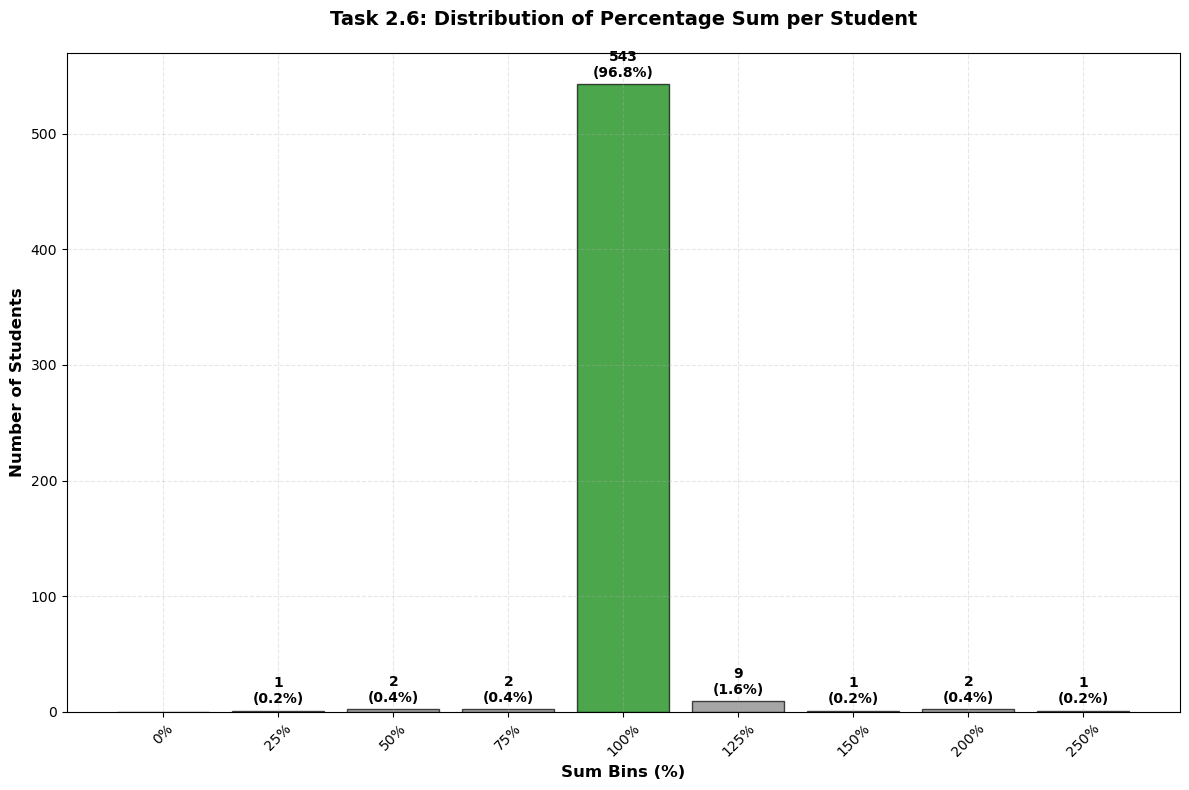

2025-10-30 15:17:00,683 - INFO - Preparing combination data for analysis...
2025-10-30 15:17:00,686 - INFO - Preparing Task 2.6 data...
2025-10-30 15:17:00,688 - INFO - Retrieved 1976 responses for Task 2.6
2025-10-30 15:17:00,686 - INFO - Preparing Task 2.6 data...
2025-10-30 15:17:00,688 - INFO - Retrieved 1976 responses for Task 2.6
2025-10-30 15:17:00,816 - INFO - Prepared data for 561 students
2025-10-30 15:17:00,819 - INFO - Analysis will focus on 543 students with 100% sum
2025-10-30 15:17:00,816 - INFO - Prepared data for 561 students
2025-10-30 15:17:00,819 - INFO - Analysis will focus on 543 students with 100% sum
2025-10-30 15:17:00,819 - INFO - Creating combination distribution visualization...
2025-10-30 15:17:00,819 - INFO - Creating combination distribution visualization...


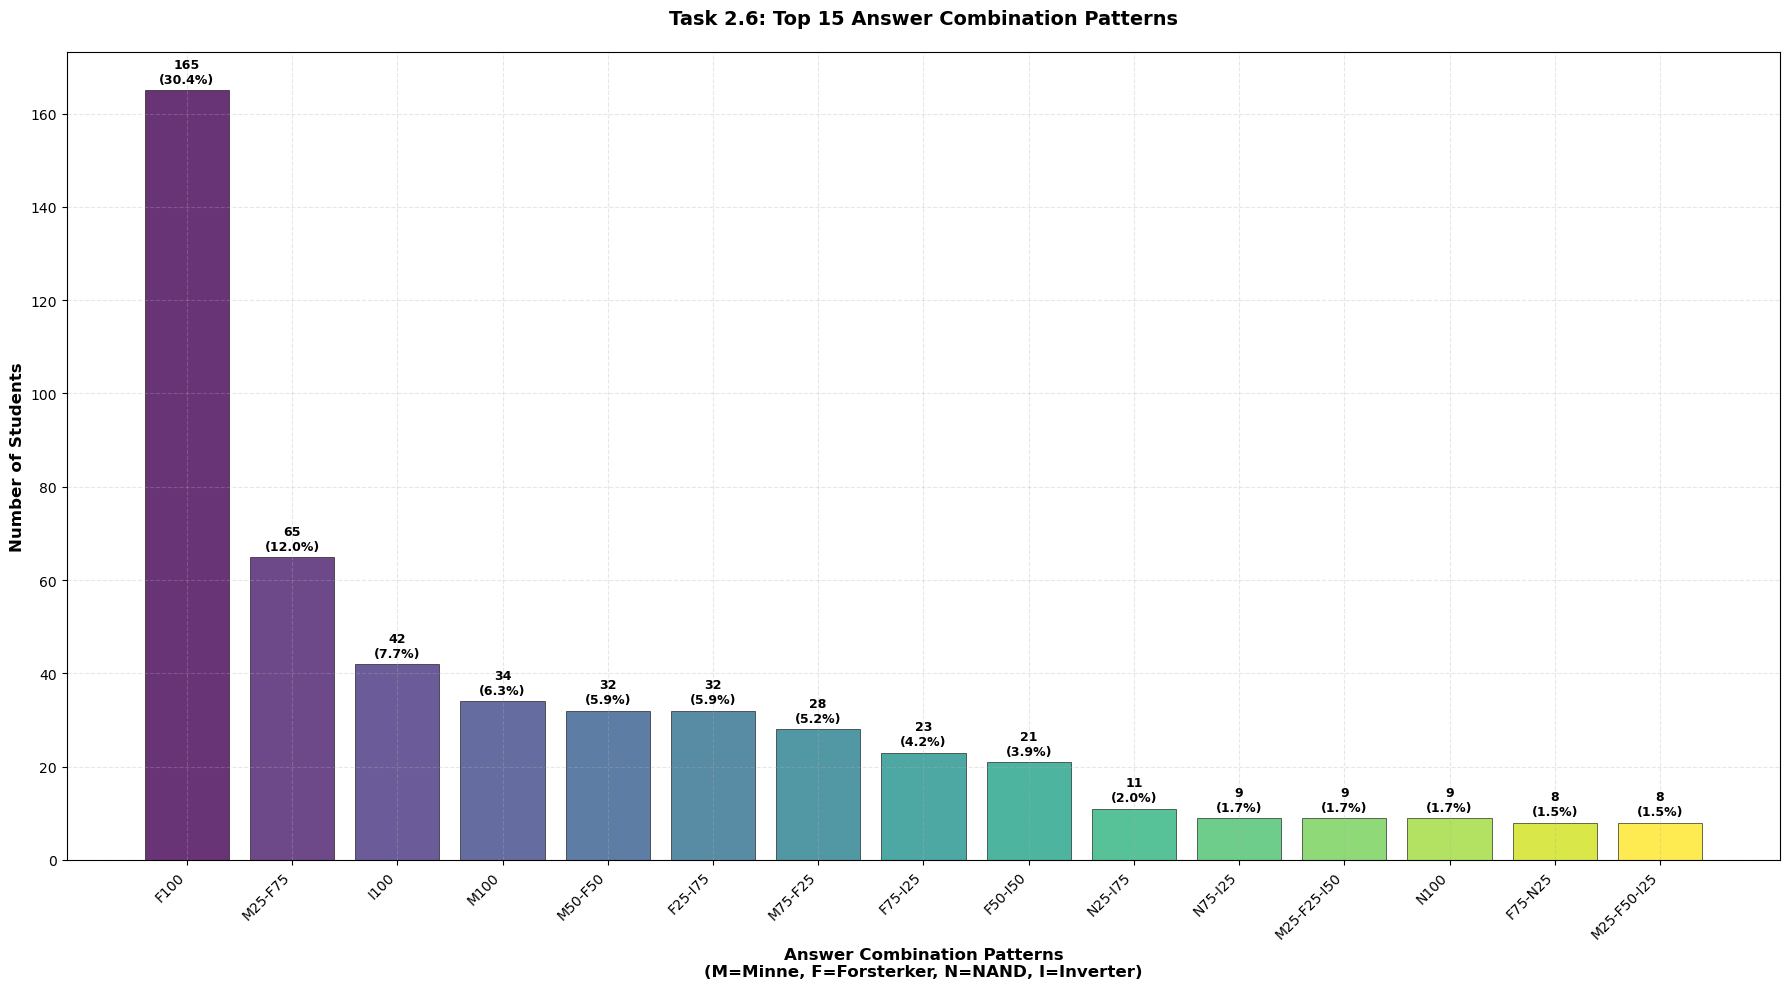

2025-10-30 15:17:01,164 - INFO - Creating gender-specific combination distribution visualizations...


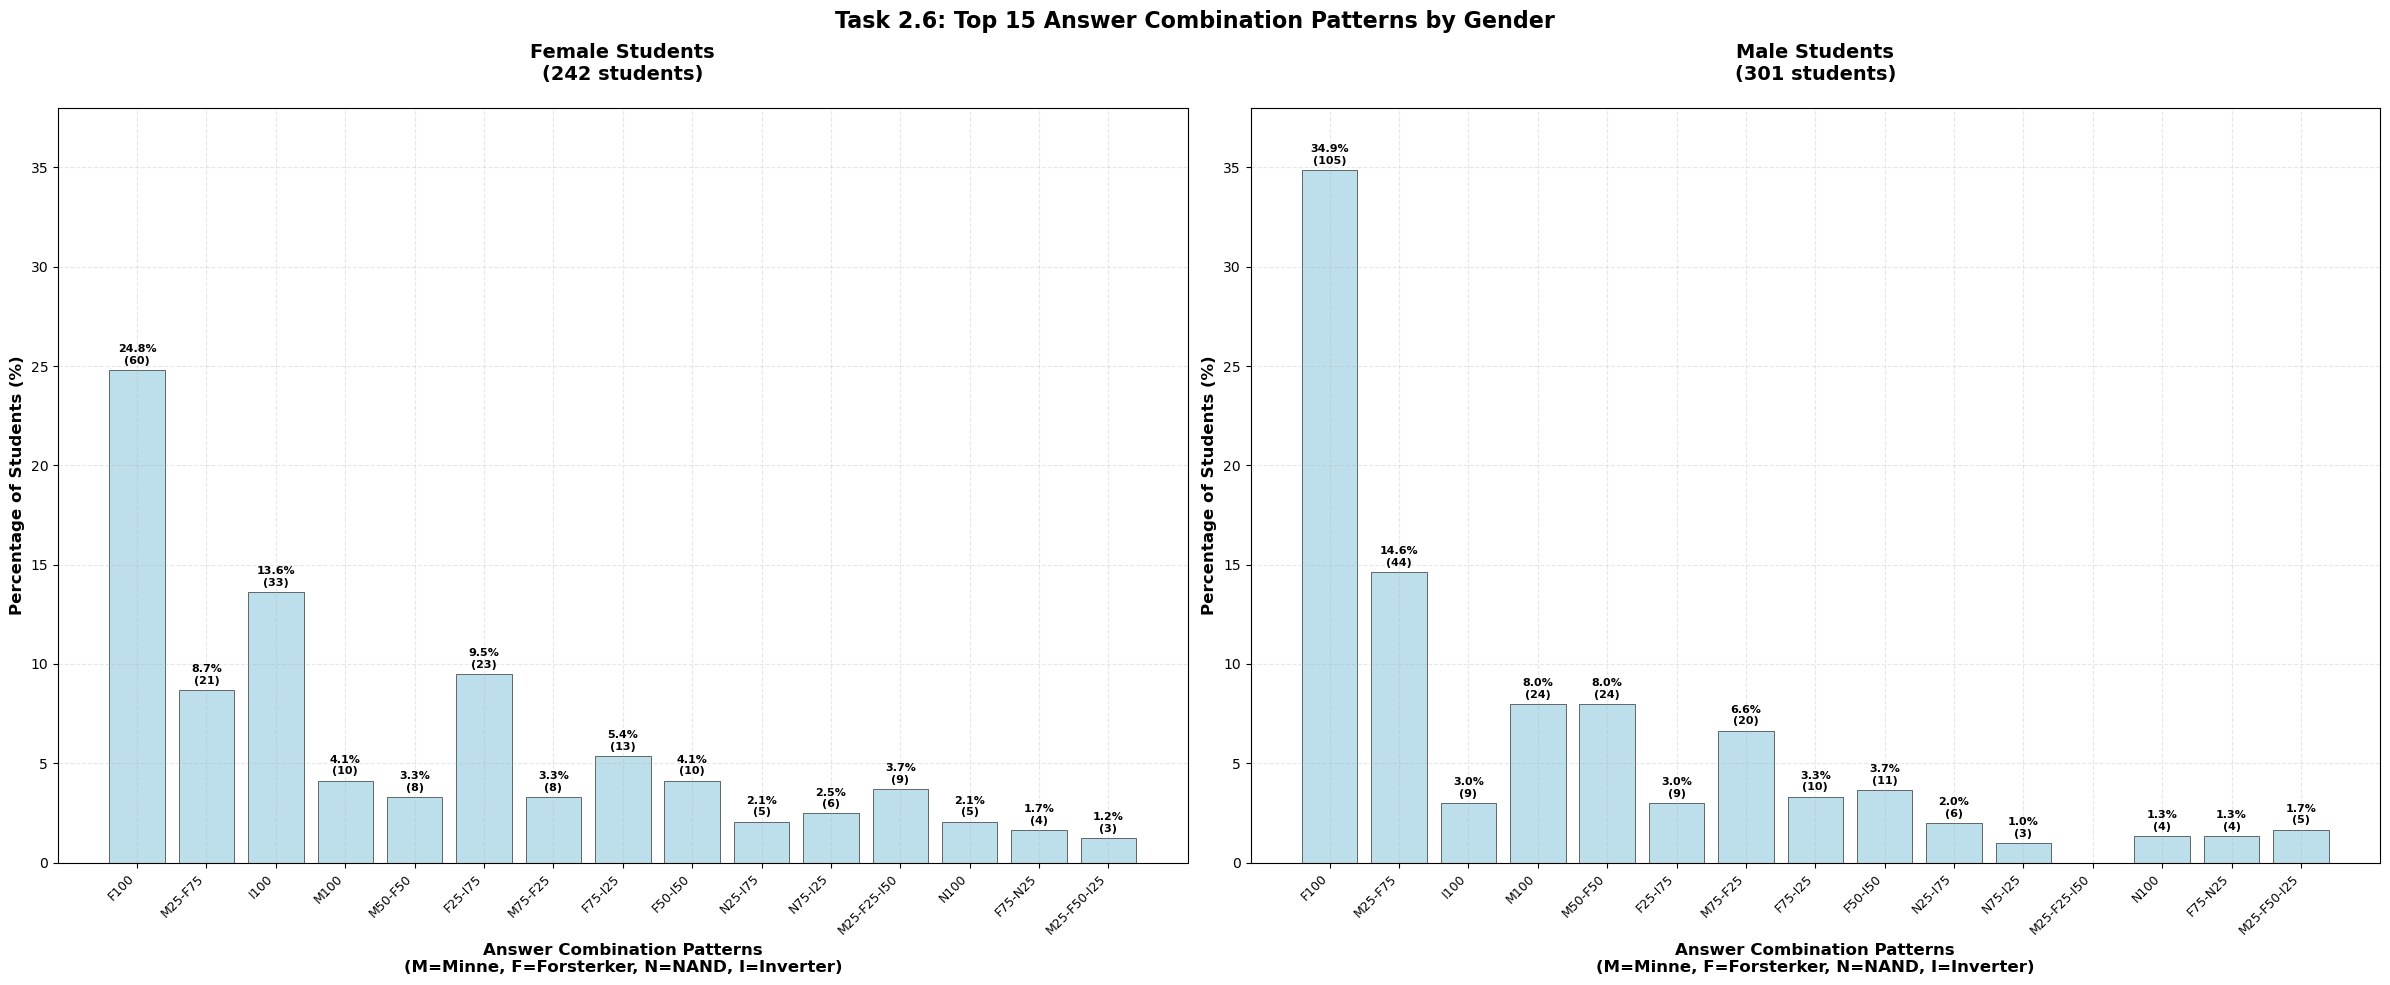

2025-10-30 15:17:01,694 - INFO - 
2025-10-30 15:17:01,694 - INFO - GENDER-SPECIFIC ANALYSIS SUMMARY
2025-10-30 15:17:01,695 - INFO - ============================================================
2025-10-30 15:17:01,697 - INFO - Female students:
2025-10-30 15:17:01,697 - INFO -   - Total: 242
2025-10-30 15:17:01,698 - INFO -   - Most popular combination: F100 (60 students)
2025-10-30 15:17:01,698 - INFO -   - Unique combinations: 30
2025-10-30 15:17:01,700 - INFO - Male students:
2025-10-30 15:17:01,700 - INFO -   - Total: 301
2025-10-30 15:17:01,701 - INFO -   - Most popular combination: F100 (105 students)
2025-10-30 15:17:01,701 - INFO -   - Unique combinations: 24
2025-10-30 15:17:01,702 - INFO - ============================================================
2025-10-30 15:17:01,702 - INFO - Creating answer alternatives by gender visualization...
2025-10-30 15:17:01,694 - INFO - GENDER-SPECIFIC ANALYSIS SUMMARY
2025-10-30 15:17:01,695 - INFO - ===========================================

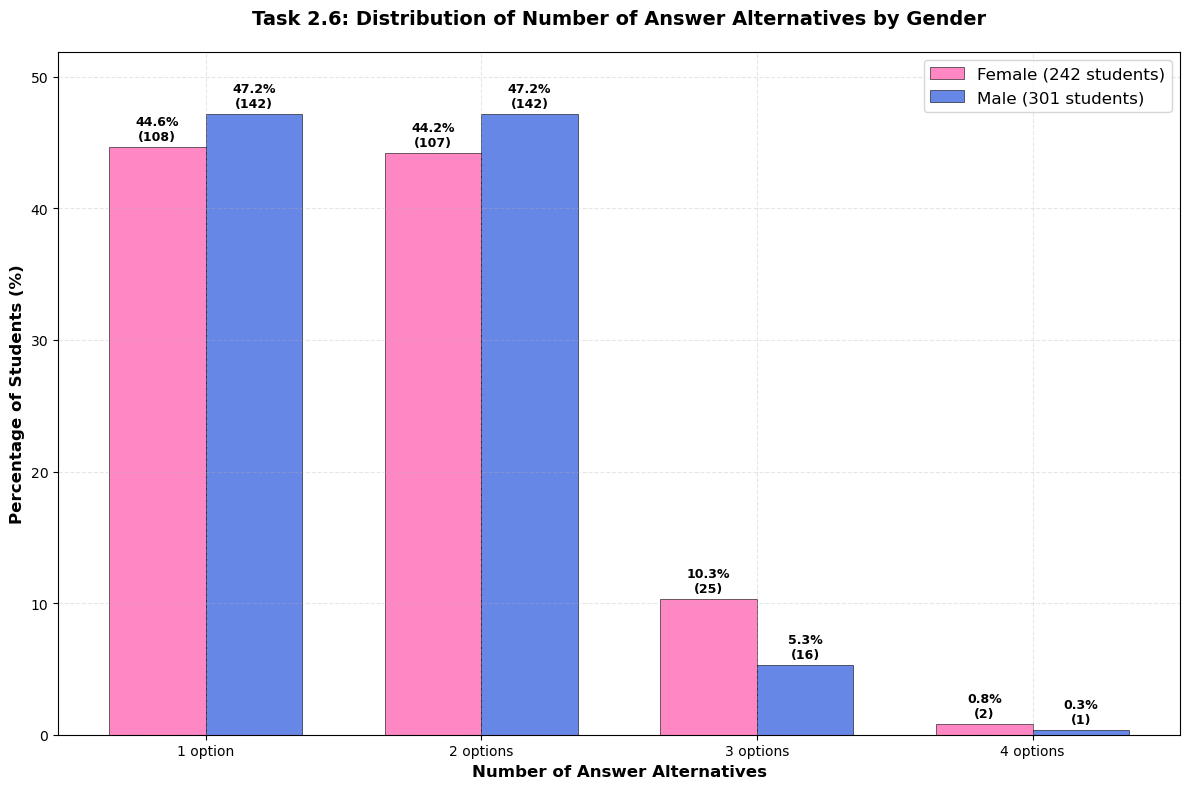

2025-10-30 15:17:01,927 - INFO - 
2025-10-30 15:17:01,928 - INFO - ANSWER ALTERNATIVES BY GENDER SUMMARY
2025-10-30 15:17:01,928 - INFO - ==================================================
2025-10-30 15:17:01,930 - INFO - Female students (242 total):
2025-10-30 15:17:01,931 - INFO -   - 1 option: 108 students (44.6%)
2025-10-30 15:17:01,931 - INFO -   - 2 options: 107 students (44.2%)
2025-10-30 15:17:01,931 - INFO -   - 3 options: 25 students (10.3%)
2025-10-30 15:17:01,932 - INFO -   - 4 options: 2 students (0.8%)
2025-10-30 15:17:01,933 - INFO - Male students (301 total):
2025-10-30 15:17:01,934 - INFO -   - 1 option: 142 students (47.2%)
2025-10-30 15:17:01,934 - INFO -   - 2 options: 142 students (47.2%)
2025-10-30 15:17:01,934 - INFO -   - 3 options: 16 students (5.3%)
2025-10-30 15:17:01,935 - INFO -   - 4 options: 1 students (0.3%)
2025-10-30 15:17:01,935 - INFO - ==================================================
2025-10-30 15:17:01,936 - INFO - Creating grade-specific heatmap

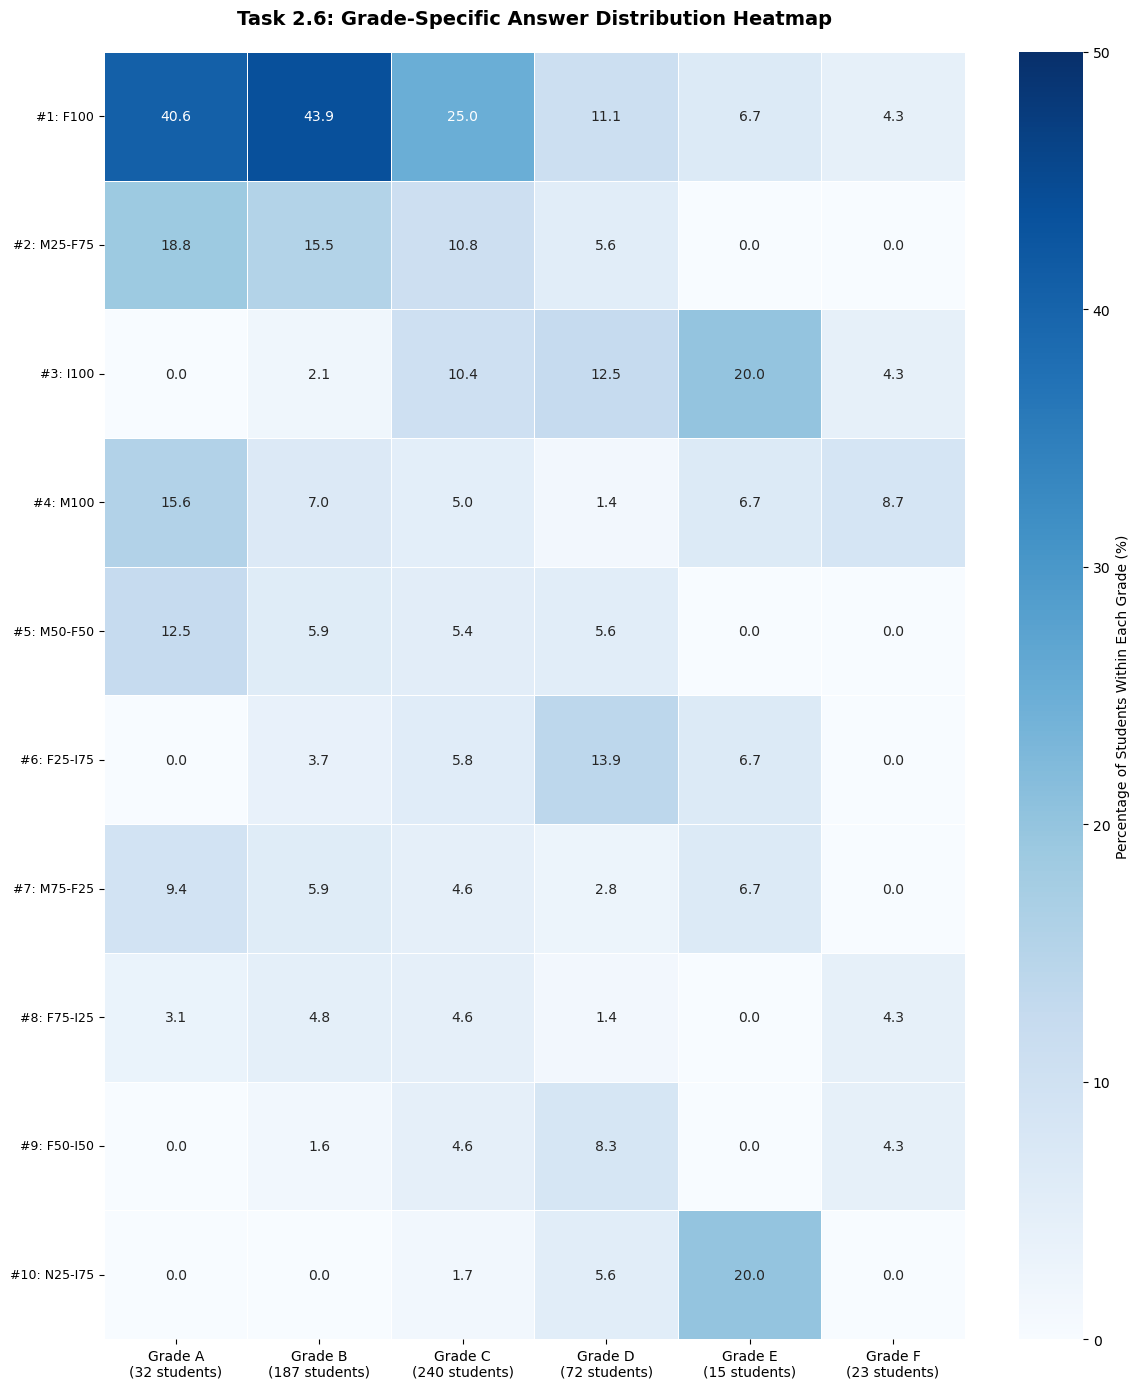

2025-10-30 15:17:02,273 - INFO - Creating quartile-specific heatmap...


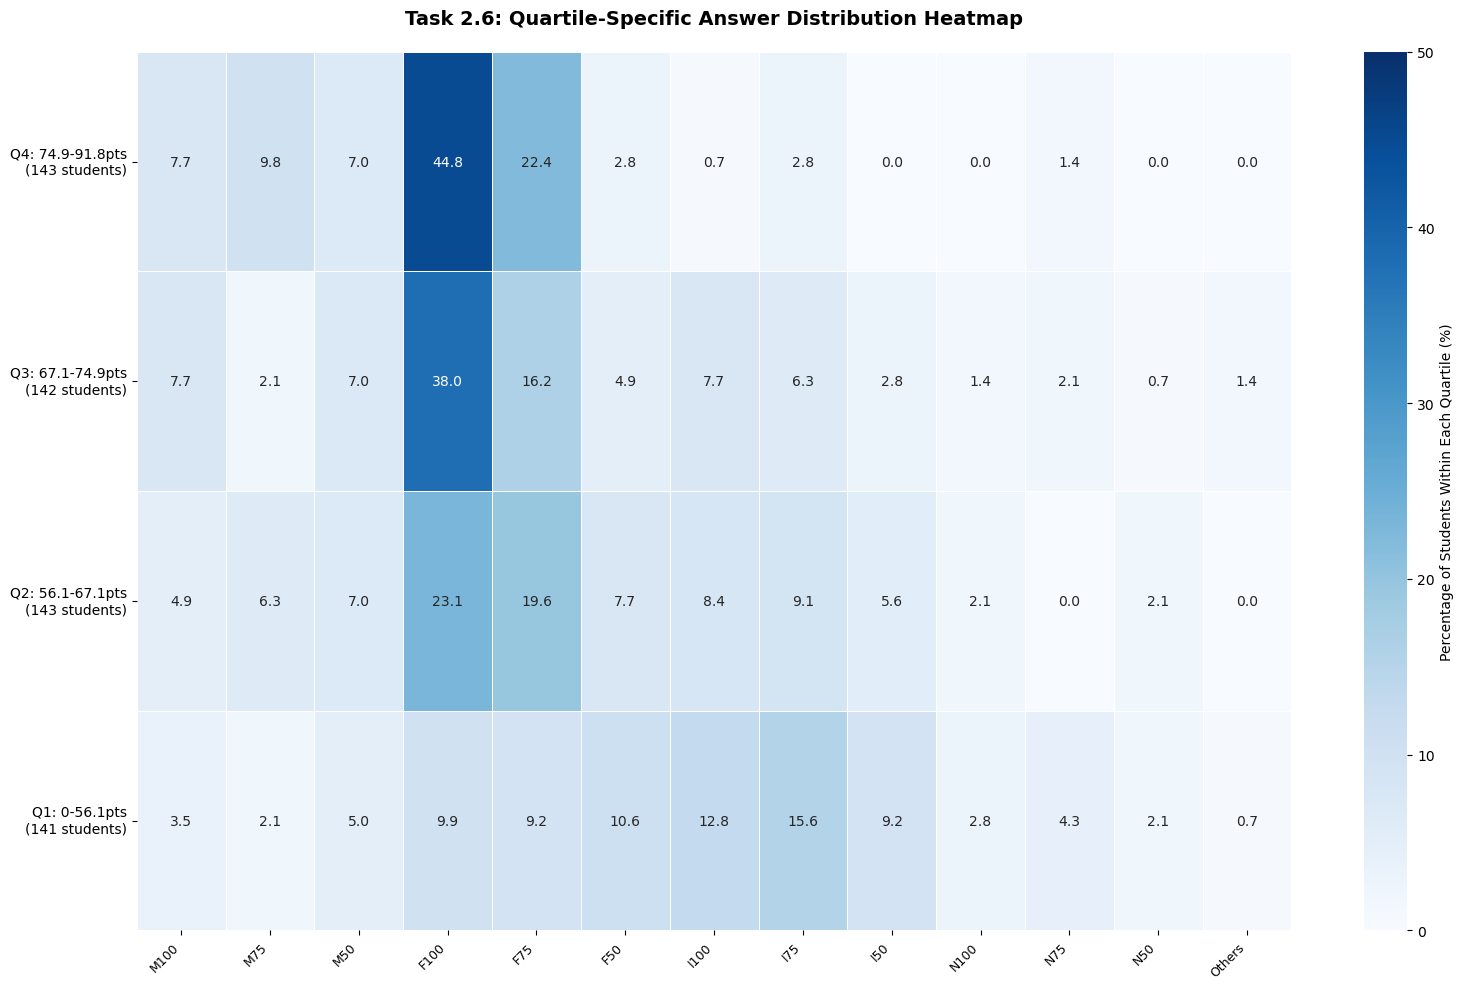

2025-10-30 15:17:02,644 - INFO - 
2025-10-30 15:17:02,645 - INFO - ANALYSIS SUMMARY
2025-10-30 15:17:02,646 - INFO - ============================================================
2025-10-30 15:17:02,647 - INFO - Total students analyzed: 561
2025-10-30 15:17:02,647 - INFO - Students with 100% sum: 543
2025-10-30 15:17:02,648 - INFO - Most popular combination: F100 (165 students)
2025-10-30 15:17:02,649 - INFO - Total unique combinations: 15
2025-10-30 15:17:02,649 - INFO - ============================================================
2025-10-30 15:17:02,645 - INFO - ANALYSIS SUMMARY
2025-10-30 15:17:02,646 - INFO - ============================================================
2025-10-30 15:17:02,647 - INFO - Total students analyzed: 561
2025-10-30 15:17:02,647 - INFO - Students with 100% sum: 543
2025-10-30 15:17:02,648 - INFO - Most popular combination: F100 (165 students)
2025-10-30 15:17:02,649 - INFO - Total unique combinations: 15
2025-10-30 15:17:02,649 - INFO - =====================

In [5]:
# ============================================================================
# CONSOLIDATED ANALYSIS EXECUTION
# ============================================================================

# 1. Display percentage sum distribution
logger.info("Creating percentage sum distribution visualization...")
visualizer.plot_percentage_distribution(sums_analysis)

# 2. Prepare combination data from complete dataset
logger.info("Preparing combination data for analysis...")
complete_working_data = analyzer.prepare_data(df)

# Filter for students with 100% sum only
valid_students = analyzer.pivot_data[
    analyzer.pivot_data[["Minne", "Forsterker", "NAND", "Inverter"]].sum(axis=1) == 100
].index

combination_data = analyzer.pivot_data.loc[valid_students].reset_index()

logger.info(f"Analysis will focus on {len(combination_data)} students with 100% sum")

# 3. Create combination distribution chart
logger.info("Creating combination distribution visualization...")
combination_stats = visualizer.plot_combination_distribution(combination_data, top_n=15)

# 3.1. Create gender-specific combination distribution charts
logger.info("Creating gender-specific combination distribution visualizations...")
visualizer.plot_gender_combination_distribution(df, combination_data, top_n=15)

# 3.2. Create answer alternatives by gender chart
logger.info("Creating answer alternatives by gender visualization...")
visualizer.plot_answer_alternatives_by_gender(df, combination_data)

# 4. Create grade-specific heatmap
logger.info("Creating grade-specific heatmap...")
visualizer.plot_grade_heatmap(df, combination_data, top_n=10)

# 5. Create quartile-specific heatmap
logger.info("Creating quartile-specific heatmap...")
visualizer.plot_quartile_heatmap(df, combination_data)

# Print summary statistics
logger.info("\n" + "="*60)
logger.info("ANALYSIS SUMMARY")
logger.info("="*60)
logger.info(f"Total students analyzed: {len(analyzer.pivot_data) if analyzer.pivot_data is not None else 0}")
logger.info(f"Students with 100% sum: {len(combination_data)}")
logger.info(f"Most popular combination: {combination_stats.index[0]} ({combination_stats.iloc[0]} students)")
logger.info(f"Total unique combinations: {len(combination_stats)}")
logger.info("="*60)